# 🎬 Movie Success Prediction
## Using Naïve Bayes, Logistic Regression & Support Vector Machine
**Project Type:** Classification — AI/ML Internship Submission  
**Objective:** Predict whether a movie will be a *Hit* or *Flop* based on features like genre, budget, runtime, cast popularity, and more.  
**Algorithms Used:**
- 🔵 Naïve Bayes (Gaussian NB)
- 🟢 Logistic Regression
- 🔴 Support Vector Machine (SVM)

---

## 📦 Step 1 — Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 🎲 Step 2 — Create Synthetic Movie Dataset

> **Note:** A realistic 1000-movie synthetic dataset is used to simulate real-world movie data with features like budget, cast popularity, critic score, genre, and more.


In [2]:
# Step 2: Create Synthetic Movie Dataset


In [3]:
np.random.seed(42)
n = 1000

genres = ['Action', 'Comedy', 'Drama', 'Horror', 'Romance', 'Sci-Fi', 'Thriller', 'Animation']
languages = ['English', 'Hindi', 'Spanish', 'French', 'Korean']
seasons = ['Summer', 'Winter', 'Spring', 'Fall']

budget          = np.random.randint(1, 300, n)          # in million $
runtime         = np.random.randint(70, 200, n)         # minutes
cast_popularity = np.random.uniform(1, 10, n)           # 1–10 star score
director_score  = np.random.uniform(1, 10, n)           # past success rate
marketing_spend = np.random.randint(1, 100, n)          # in million $
num_screens     = np.random.randint(500, 5000, n)       # theater screens
critic_score    = np.random.uniform(1, 10, n)           # Rotten Tomatoes style
sequel_flag     = np.random.randint(0, 2, n)            # 1 = sequel
genre           = np.random.choice(genres, n)
language        = np.random.choice(languages, n)
release_season  = np.random.choice(seasons, n)

# Target: Hit (1) or Flop (0) — influenced by budget, cast, critic score
score = (
    0.30 * (budget / 300) +
    0.20 * (cast_popularity / 10) +
    0.20 * (critic_score / 10) +
    0.15 * (director_score / 10) +
    0.10 * (marketing_spend / 100) +
    0.05 * sequel_flag
)
noise = np.random.normal(0, 0.1, n)
success = (score + noise > 0.42).astype(int)  # ~55% Hit rate

df = pd.DataFrame({
    'Budget_M':        budget,
    'Runtime_min':     runtime,
    'Cast_Popularity': cast_popularity.round(2),
    'Director_Score':  director_score.round(2),
    'Marketing_M':     marketing_spend,
    'Num_Screens':     num_screens,
    'Critic_Score':    critic_score.round(2),
    'Sequel':          sequel_flag,
    'Genre':           genre,
    'Language':        language,
    'Release_Season':  release_season,
    'Success':         success
})

print(f'Dataset shape: {df.shape}')
print(f'Class distribution:\n{df["Success"].value_counts().rename({0:"Flop",1:"Hit"})}')
df.head(10)

Dataset shape: (1000, 12)
Class distribution:
Success
Hit     725
Flop    275
Name: count, dtype: int64


,Budget_M,Runtime_min,Cast_Popularity,Director_Score,Marketing_M,Num_Screens,Critic_Score,Sequel,Genre,Language,Release_Season,Success
0,103,88,9.49,6.19,70,2894,3.40,0,Horror,French,Winter,1
1,271,87,3.17,4.21,59,3193,2.08,1,Romance,Korean,Fall,1
2,107,70,2.09,8.09,64,1870,3.07,1,Animation,French,Fall,1
3,72,147,2.78,3.26,18,4840,1.96,1,Drama,English,Summer,0
4,189,184,8.98,6.08,4,2656,8.40,0,Horror,Korean,Fall,1
5,21,182,6.81,4.23,17,3080,2.25,0,Drama,Spanish,Spring,0
6,103,183,3.57,6.91,14,4891,7.73,0,Romance,Korean,Summer,0
7,122,132,8.34,3.16,78,2659,1.43,0,Thriller,French,Summer,1
8,215,198,8.75,2.72,13,3748,9.54,0,Sci-Fi,Hindi,Summer,1
9,88,77,8.62,9.26,7,4231,7.40,1,Drama,Spanish,Winter,1


---
## 🔍 Step 3 — Exploratory Data Analysis (EDA)

In [4]:
# Basic info
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Budget_M         1000 non-null   int32  
 1   Runtime_min      1000 non-null   int32  
 2   Cast_Popularity  1000 non-null   float64
 3   Director_Score   1000 non-null   float64
 4   Marketing_M      1000 non-null   int32  
 5   Num_Screens      1000 non-null   int32  
 6   Critic_Score     1000 non-null   float64
 7   Sequel           1000 non-null   int32  
 8   Genre            1000 non-null   object 
 9   Language         1000 non-null   object 
 10  Release_Season   1000 non-null   object 
 11  Success          1000 non-null   int64  
dtypes: float64(3), int32(5), int64(1), object(3)
memory usage: 74.3+ KB

=== Statistical Summary ===


,Budget_M,Runtime_min,Cast_Popularity,Director_Score,Marketing_M,Num_Screens,Critic_Score,Sequel,Success
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0,1000.00
mean,150.55,132.97,5.51,5.46,49.85,2720.91,5.42,0.5,0.72
std,85.29,38.52,2.61,2.57,28.27,1301.87,2.64,0.5,0.45
min,1.00,70.00,1.00,1.00,1.00,501.00,1.01,0.0,0.00
25%,79.50,100.00,3.34,3.24,25.00,1538.25,3.08,0.0,0.00
50%,150.00,131.00,5.50,5.46,48.00,2788.50,5.44,1.0,1.00
75%,224.00,167.00,7.80,7.68,75.00,3818.75,7.60,1.0,1.00
max,299.00,199.00,9.99,10.00,99.00,4997.00,10.00,1.0,1.00


In [5]:
# Missing values check
print('=== Missing Values ===')
print(df.isnull().sum())
print('\n✅ No missing values found!')

=== Missing Values ===
Budget_M           0
Runtime_min        0
Cast_Popularity    0
Director_Score     0
Marketing_M        0
Num_Screens        0
Critic_Score       0
Sequel             0
Genre              0
Language           0
Release_Season     0
Success            0
dtype: int64

✅ No missing values found!


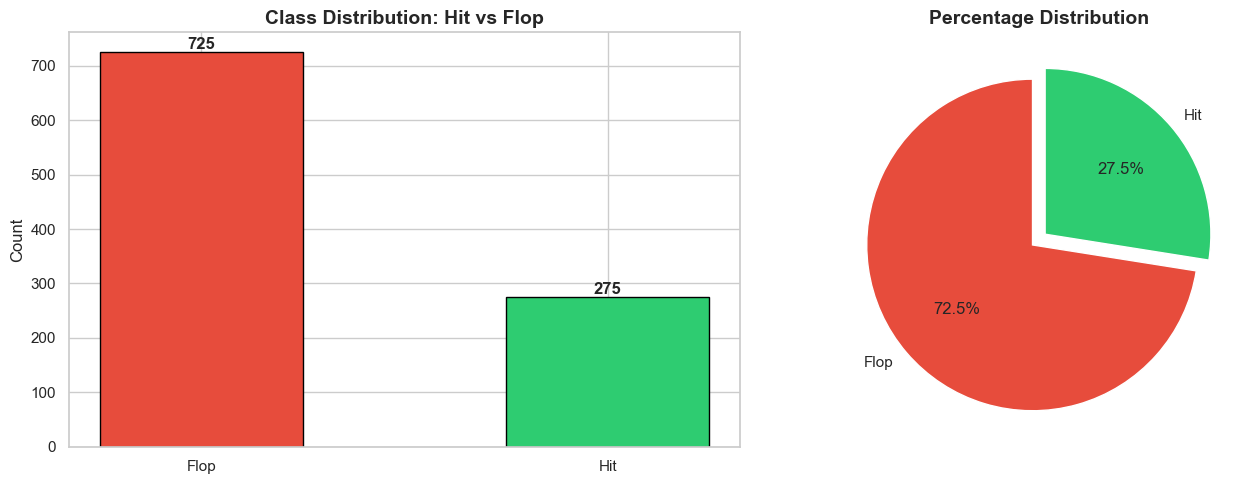

In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Flop', 'Hit']
counts = df['Success'].value_counts()
colors = ['#e74c3c', '#2ecc71']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution: Hit vs Flop', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

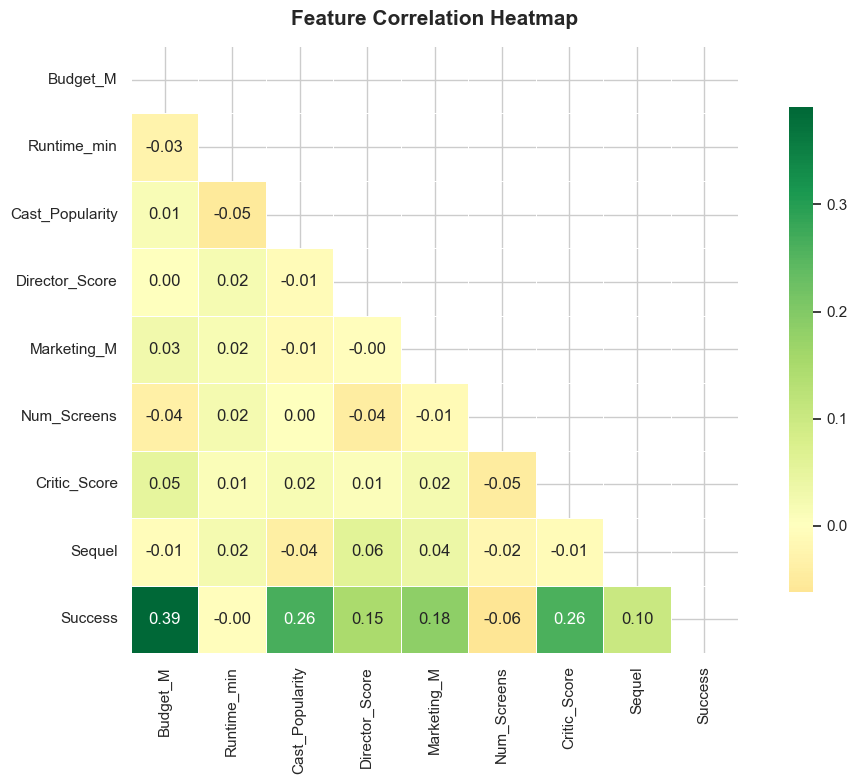

In [7]:
# Correlation heatmap (numeric features)
numeric_cols = ['Budget_M', 'Runtime_min', 'Cast_Popularity', 'Director_Score',
                'Marketing_M', 'Num_Screens', 'Critic_Score', 'Sequel', 'Success']

plt.figure(figsize=(11, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

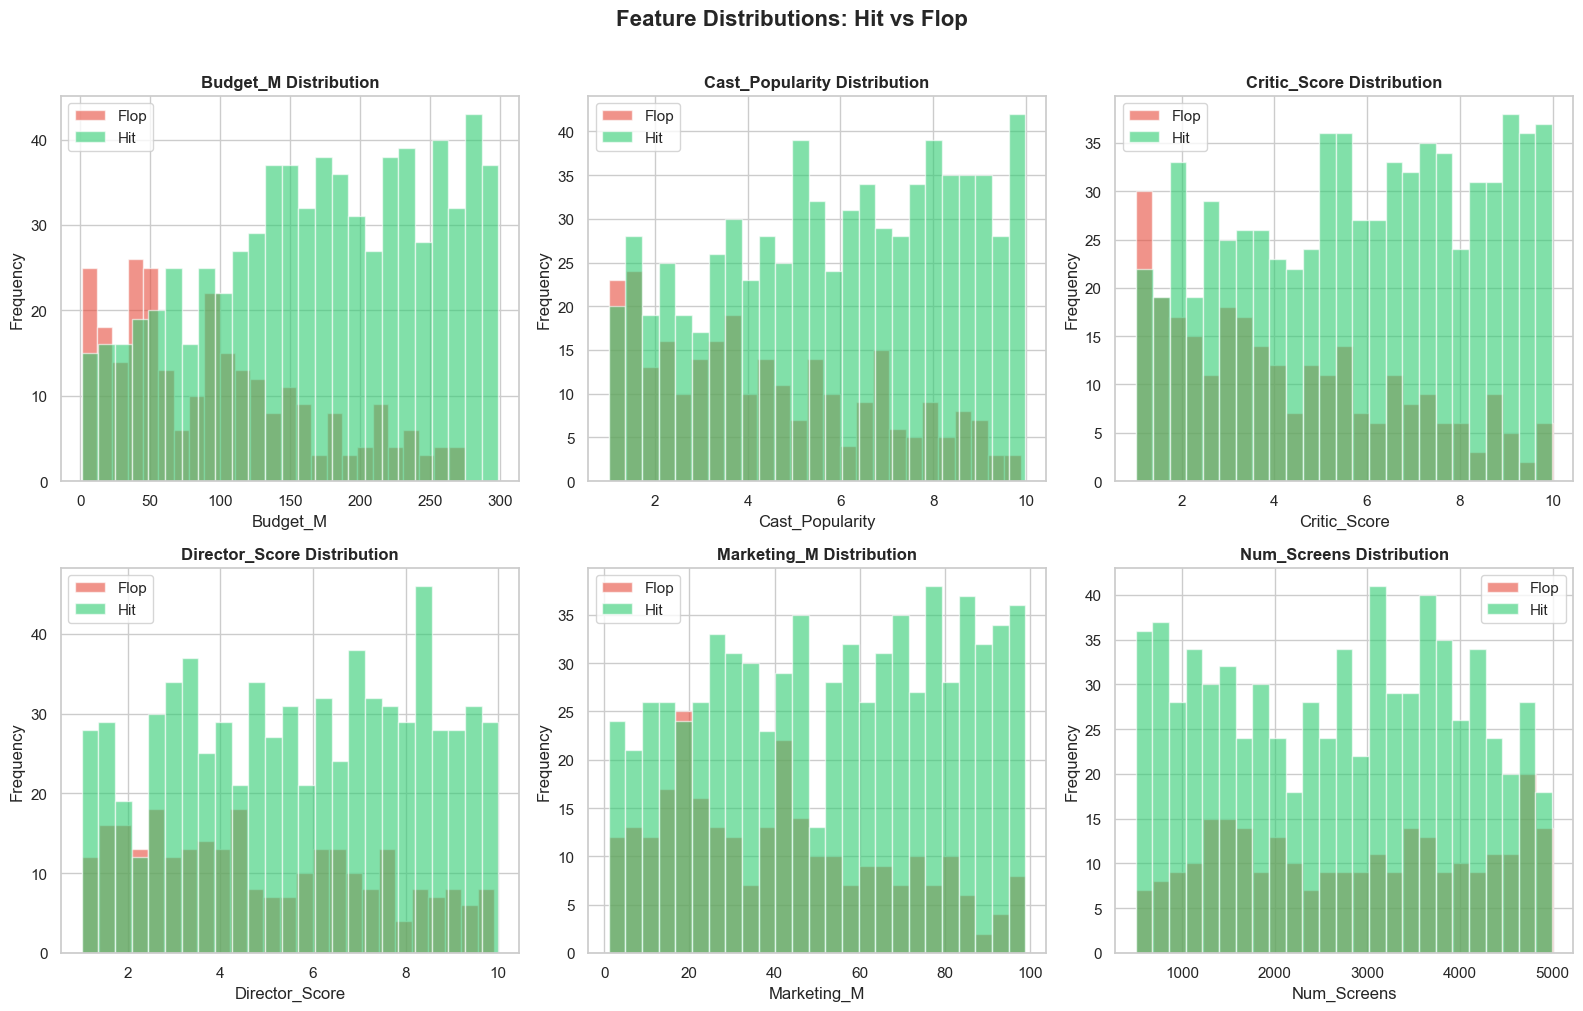

In [8]:
# Feature distributions by Success
num_features = ['Budget_M', 'Cast_Popularity', 'Critic_Score', 'Director_Score', 'Marketing_M', 'Num_Screens']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for label, color in zip([0, 1], ['#e74c3c', '#2ecc71']):
        axes[i].hist(df[df['Success'] == label][feat], bins=25, alpha=0.6,
                     color=color, label='Flop' if label == 0 else 'Hit', edgecolor='white')
    axes[i].set_title(f'{feat} Distribution', fontweight='bold')
    axes[i].legend()
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Feature Distributions: Hit vs Flop', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

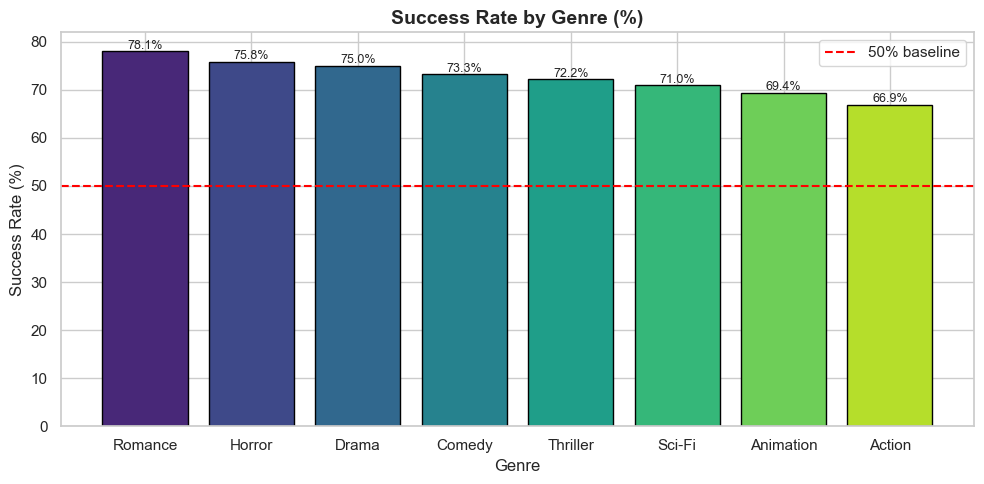

In [9]:
# Genre-wise success rate
genre_success = df.groupby('Genre')['Success'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(genre_success.index, genre_success.values * 100,
               color=sns.color_palette('viridis', len(genre_success)), edgecolor='black')
plt.axhline(y=50, color='red', linestyle='--', label='50% baseline')
plt.title('Success Rate by Genre (%)', fontsize=14, fontweight='bold')
plt.ylabel('Success Rate (%)')
plt.xlabel('Genre')
plt.legend()
for bar, val in zip(bars, genre_success.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('genre_success_rate.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🛠️ Step 4 — Data Preprocessing

In [10]:
# Label Encoding for categorical features
le_genre   = LabelEncoder()
le_lang    = LabelEncoder()
le_season  = LabelEncoder()

df_encoded = df.copy()
df_encoded['Genre']          = le_genre.fit_transform(df['Genre'])
df_encoded['Language']       = le_lang.fit_transform(df['Language'])
df_encoded['Release_Season'] = le_season.fit_transform(df['Release_Season'])

print('Label Encoding complete.')
print(f'Genre classes:   {list(le_genre.classes_)}')
print(f'Language classes: {list(le_lang.classes_)}')
print(f'Season classes:  {list(le_season.classes_)}')

Label Encoding complete.
Genre classes:   ['Action', 'Animation', 'Comedy', 'Drama', 'Horror', 'Romance', 'Sci-Fi', 'Thriller']
Language classes: ['English', 'French', 'Hindi', 'Korean', 'Spanish']
Season classes:  ['Fall', 'Spring', 'Summer', 'Winter']


In [11]:
# Define features (X) and target (y)
feature_cols = ['Budget_M', 'Runtime_min', 'Cast_Popularity', 'Director_Score',
                'Marketing_M', 'Num_Screens', 'Critic_Score', 'Sequel',
                'Genre', 'Language', 'Release_Season']

X = df_encoded[feature_cols]
y = df_encoded['Success']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Training samples : 800
Testing samples  : 200
Features         : 11


In [12]:
# Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Feature scaling applied (StandardScaler)')
print(f'  Train mean ≈ {X_train_scaled.mean():.4f} (should be ~0)')
print(f'  Train std  ≈ {X_train_scaled.std():.4f}  (should be ~1)')

✅ Feature scaling applied (StandardScaler)
  Train mean ≈ -0.0000 (should be ~0)
  Train std  ≈ 1.0000  (should be ~1)


---
## 🔵 Step 5 — Model 1: Naïve Bayes (Gaussian NB)

In [13]:
# Train Naïve Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Predict
nb_pred      = nb_model.predict(X_test_scaled)
nb_pred_prob = nb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
nb_acc = accuracy_score(y_test, nb_pred)
nb_auc = roc_auc_score(y_test, nb_pred_prob)
nb_cv  = cross_val_score(nb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('=' * 50)
print('         NAÏVE BAYES — Results')
print('=' * 50)
print(f'  Test Accuracy  : {nb_acc:.4f} ({nb_acc*100:.2f}%)')
print(f'  ROC-AUC Score  : {nb_auc:.4f}')
print(f'  CV Accuracy    : {nb_cv.mean():.4f} ± {nb_cv.std():.4f}')
print()
print(classification_report(y_test, nb_pred, target_names=['Flop', 'Hit']))

         NAÏVE BAYES — Results
  Test Accuracy  : 0.7950 (79.50%)
  ROC-AUC Score  : 0.8567
  CV Accuracy    : 0.8087 ± 0.0211

              precision    recall  f1-score   support

        Flop       0.68      0.47      0.56        55
         Hit       0.82      0.92      0.87       145

    accuracy                           0.80       200
   macro avg       0.75      0.69      0.71       200
weighted avg       0.78      0.80      0.78       200



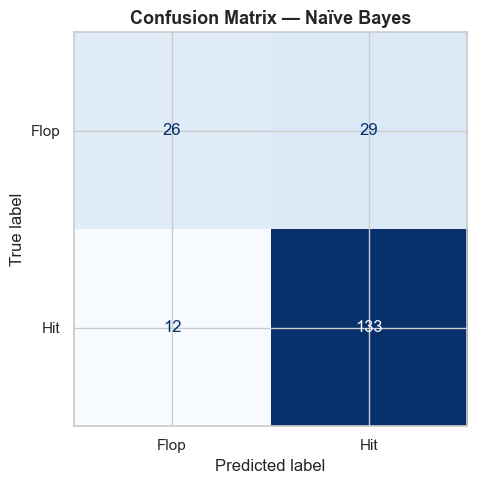

In [14]:
# Confusion Matrix — Naïve Bayes
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, nb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Flop', 'Hit'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Naïve Bayes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_naive_bayes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🟢 Step 6 — Model 2: Logistic Regression

In [15]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_pred      = lr_model.predict(X_test_scaled)
lr_pred_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_pred_prob)
lr_cv  = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('=' * 50)
print('      LOGISTIC REGRESSION — Results')
print('=' * 50)
print(f'  Test Accuracy  : {lr_acc:.4f} ({lr_acc*100:.2f}%)')
print(f'  ROC-AUC Score  : {lr_auc:.4f}')
print(f'  CV Accuracy    : {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')
print()
print(classification_report(y_test, lr_pred, target_names=['Flop', 'Hit']))

      LOGISTIC REGRESSION — Results
  Test Accuracy  : 0.8150 (81.50%)
  ROC-AUC Score  : 0.8643
  CV Accuracy    : 0.8113 ± 0.0263

              precision    recall  f1-score   support

        Flop       0.71      0.55      0.62        55
         Hit       0.84      0.92      0.88       145

    accuracy                           0.81       200
   macro avg       0.78      0.73      0.75       200
weighted avg       0.81      0.81      0.81       200



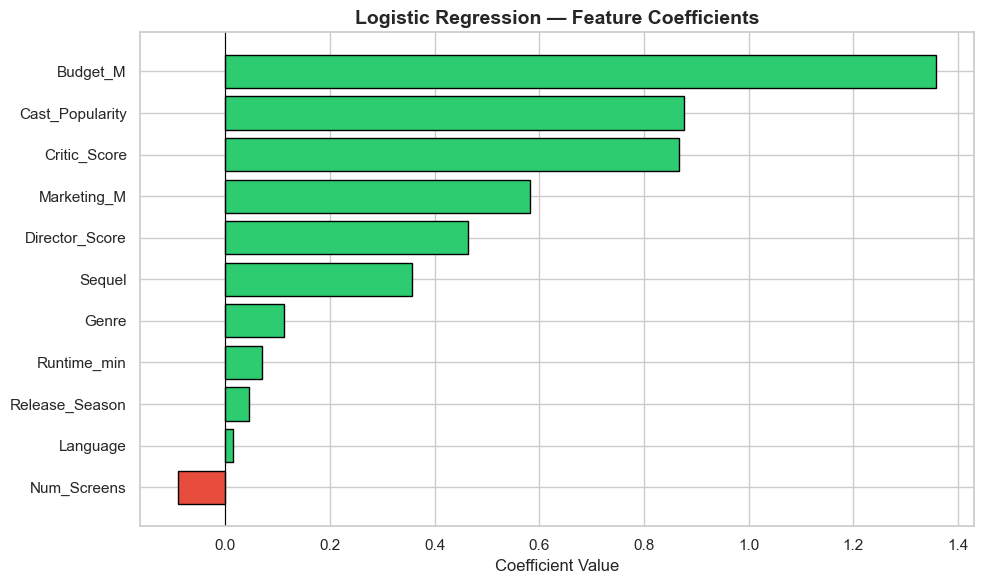

Green = Positive impact (increases success probability)
Red   = Negative impact (decreases success probability)


In [16]:
# Feature Coefficients — Logistic Regression
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Green = Positive impact (increases success probability)')
print('Red   = Negative impact (decreases success probability)')

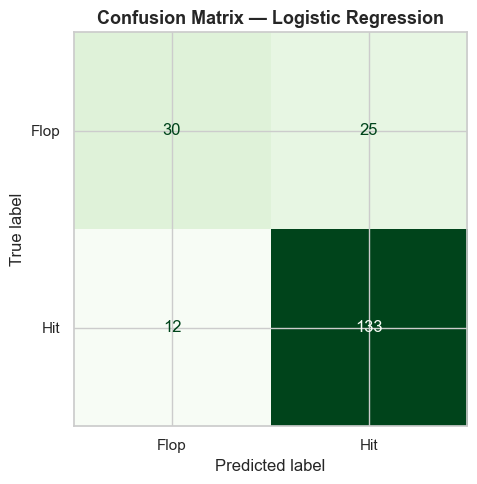

In [17]:
# Confusion Matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Flop', 'Hit'])
disp.plot(cmap='Greens', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔴 Step 7 — Model 3: Support Vector Machine (SVM)

In [18]:
# Train SVM (RBF Kernel)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predict
svm_pred      = svm_model.predict(X_test_scaled)
svm_pred_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
svm_acc = accuracy_score(y_test, svm_pred)
svm_auc = roc_auc_score(y_test, svm_pred_prob)
svm_cv  = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('=' * 50)
print('           SVM (RBF) — Results')
print('=' * 50)
print(f'  Test Accuracy  : {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print(f'  ROC-AUC Score  : {svm_auc:.4f}')
print(f'  CV Accuracy    : {svm_cv.mean():.4f} ± {svm_cv.std():.4f}')
print()
print(classification_report(y_test, svm_pred, target_names=['Flop', 'Hit']))

           SVM (RBF) — Results
  Test Accuracy  : 0.8050 (80.50%)
  ROC-AUC Score  : 0.8594
  CV Accuracy    : 0.7900 ± 0.0239

              precision    recall  f1-score   support

        Flop       0.72      0.47      0.57        55
         Hit       0.82      0.93      0.87       145

    accuracy                           0.81       200
   macro avg       0.77      0.70      0.72       200
weighted avg       0.80      0.81      0.79       200



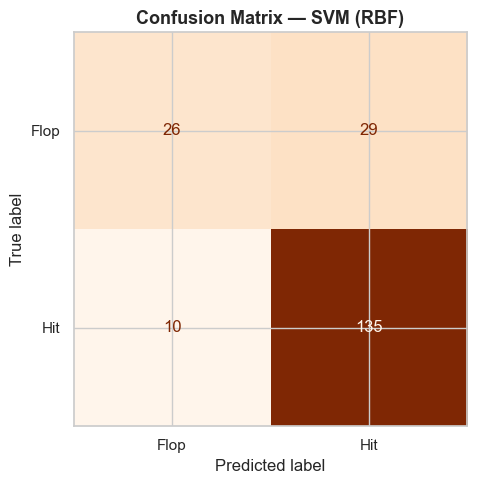

In [19]:
# Confusion Matrix — SVM
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Flop', 'Hit'])
disp.plot(cmap='Oranges', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — SVM (RBF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 Step 8 — Model Comparison & ROC Curves

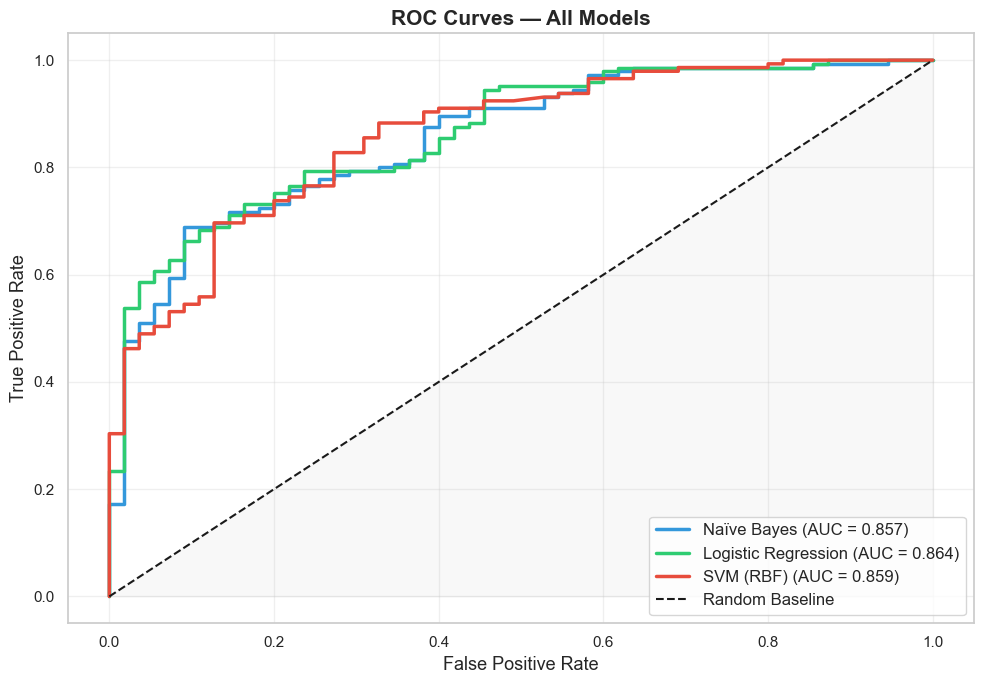

In [20]:
# ROC Curves — All Models
fig, ax = plt.subplots(figsize=(10, 7))

models_roc = [
    ('Naïve Bayes',         nb_pred_prob,  '#3498db'),
    ('Logistic Regression', lr_pred_prob,  '#2ecc71'),
    ('SVM (RBF)',           svm_pred_prob, '#e74c3c'),
]

for name, probs, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2.5, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Model Comparison Summary Table
comparison_df = pd.DataFrame({
    'Model': ['Naïve Bayes', 'Logistic Regression', 'SVM (RBF)'],
    'Test Accuracy': [round(nb_acc, 4), round(lr_acc, 4), round(svm_acc, 4)],
    'ROC-AUC': [round(nb_auc, 4), round(lr_auc, 4), round(svm_auc, 4)],
    'CV Mean Acc': [round(nb_cv.mean(), 4), round(lr_cv.mean(), 4), round(svm_cv.mean(), 4)],
    'CV Std': [round(nb_cv.std(), 4), round(lr_cv.std(), 4), round(svm_cv.std(), 4)]
})

comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
comparison_df.index = comparison_df.index + 1  # rank from 1
comparison_df.index.name = 'Rank'

print('=' * 65)
print('             MODEL PERFORMANCE COMPARISON')
print('=' * 65)
print(comparison_df.to_string())
print('=' * 65)
best_model = comparison_df.iloc[0]['Model']
print(f'\n🏆 Best Model: {best_model}')

             MODEL PERFORMANCE COMPARISON
                    Model  Test Accuracy  ROC-AUC  CV Mean Acc  CV Std
Rank                                                                  
1     Logistic Regression          0.815   0.8643       0.8112  0.0263
2               SVM (RBF)          0.805   0.8594       0.7900  0.0239
3             Naïve Bayes          0.795   0.8567       0.8087  0.0211

🏆 Best Model: Logistic Regression


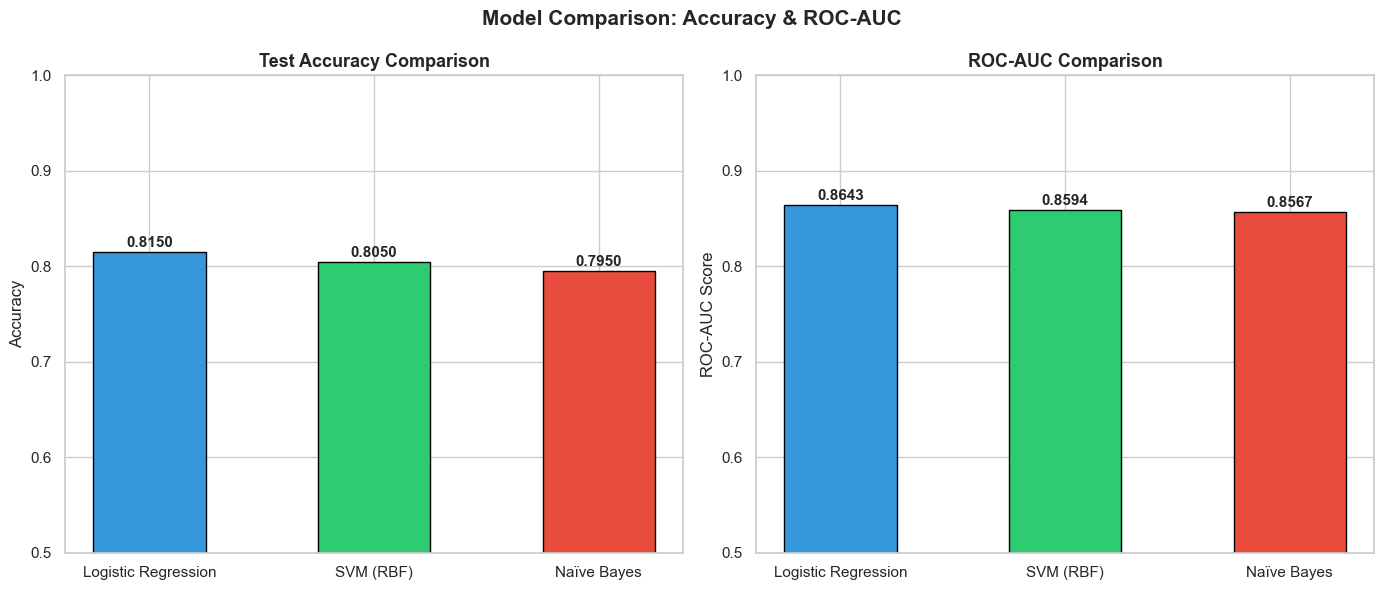

In [22]:
# Bar Chart: Accuracy & AUC Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names = comparison_df['Model'].values
colors_bar  = ['#3498db', '#2ecc71', '#e74c3c']

# Accuracy
bars1 = axes[0].bar(model_names, comparison_df['Test Accuracy'].values,
                    color=colors_bar, edgecolor='black', width=0.5)
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
for bar, val in zip(bars1, comparison_df['Test Accuracy'].values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# ROC-AUC
bars2 = axes[1].bar(model_names, comparison_df['ROC-AUC'].values,
                    color=colors_bar, edgecolor='black', width=0.5)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
for bar, val in zip(bars2, comparison_df['ROC-AUC'].values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Model Comparison: Accuracy & ROC-AUC', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 Step 9 — Hyperparameter Tuning (Best Model)

In [23]:
# Hyperparameter tuning for Logistic Regression using GridSearchCV
print('Running GridSearchCV for Logistic Regression...')
lr_params = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

lr_grid = GridSearchCV(LogisticRegression(random_state=42), lr_params,
                       cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
lr_grid.fit(X_train_scaled, y_train)

print(f'Best Params  : {lr_grid.best_params_}')
print(f'Best CV Acc  : {lr_grid.best_score_:.4f}')

# Evaluate tuned model
lr_tuned_pred = lr_grid.best_estimator_.predict(X_test_scaled)
lr_tuned_acc  = accuracy_score(y_test, lr_tuned_pred)
print(f'Tuned Test Accuracy: {lr_tuned_acc:.4f}')

Running GridSearchCV for Logistic Regression...
Best Params  : {'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}
Best CV Acc  : 0.8138
Tuned Test Accuracy: 0.8150


In [24]:
# Hyperparameter tuning for SVM
print('Running GridSearchCV for SVM...')
svm_params = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params,
                        cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
svm_grid.fit(X_train_scaled, y_train)

print(f'Best Params  : {svm_grid.best_params_}')
print(f'Best CV Acc  : {svm_grid.best_score_:.4f}')

svm_tuned_pred = svm_grid.best_estimator_.predict(X_test_scaled)
svm_tuned_acc  = accuracy_score(y_test, svm_tuned_pred)
print(f'Tuned Test Accuracy: {svm_tuned_acc:.4f}')

Running GridSearchCV for SVM...
Best Params  : {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Acc  : 0.8100
Tuned Test Accuracy: 0.8150


---
## 🎯 Step 10 — Predict a New Movie

In [25]:
# Predict success for a hypothetical new movie
new_movie = pd.DataFrame([{
    'Budget_M':        150,    # $150 Million budget
    'Runtime_min':     130,    # 130 minutes
    'Cast_Popularity': 8.5,    # High star power
    'Director_Score':  7.0,    # Experienced director
    'Marketing_M':     60,     # $60M marketing
    'Num_Screens':     3500,   # Wide release
    'Critic_Score':    7.5,    # Good reviews
    'Sequel':          1,      # Is a sequel
    'Genre':           le_genre.transform(['Action'])[0],
    'Language':        le_lang.transform(['English'])[0],
    'Release_Season':  le_season.transform(['Summer'])[0]
}])

new_movie_scaled = scaler.transform(new_movie)

# Predictions from all 3 models
nb_new  = nb_model.predict_proba(new_movie_scaled)[0]
lr_new  = lr_model.predict_proba(new_movie_scaled)[0]
svm_new = svm_model.predict_proba(new_movie_scaled)[0]

print('=' * 55)
print('   NEW MOVIE — Prediction Results')
print('   Action | English | Summer | Budget $150M')
print('=' * 55)
for model_name, probs in [('Naïve Bayes', nb_new), ('Logistic Regression', lr_new), ('SVM (RBF)', svm_new)]:
    result = '🎉 HIT' if probs[1] > 0.5 else '💸 FLOP'
    print(f'  {model_name:<22}: {result}  (Hit Probability: {probs[1]*100:.1f}%)')
print('=' * 55)

   NEW MOVIE — Prediction Results
   Action | English | Summer | Budget $150M
  Naïve Bayes           : 🎉 HIT  (Hit Probability: 95.8%)
  Logistic Regression   : 🎉 HIT  (Hit Probability: 98.1%)
  SVM (RBF)             : 🎉 HIT  (Hit Probability: 95.8%)
